# E2 & E6 — Who reports serious events? (GLP-1 FDA reports)
**Owner:** Karishma  |  

**Project:** DATA230 Group 4  |  

**Data:** cleaned FDA GLP-1 reports `glp1_reports{SUFFIX}.parquet` (output of `01_data_cleaning.ipynb`)



## Questions this notebook answers

| Chart | Question | Chart type and why |
|---|---|---|
| **Act 1** | What is in this file and what is broken? | column dictionary (type, unit, missing %, verdict) + missing-rate bar |
| **E2** | Which GLP-1 drug has the largest share of *serious* reports, and how sure are we? | sorted horizontal bar + 95 % Wilson whiskers, next to a count bar (*count before you compare*) |
| **E6** | Who filed the reports for each drug? | 100 % stacked bar (categorical × categorical) |

In [28]:
import os, sys, subprocess, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
SUFFIX = ""
REPO_URL = "https://github.com/BrianJBee/data230-group4-project.git"
REPO_DIR = Path("/content/data230-group4-project")
DRIVE_FOLDER_CANDIDATES = [
    "/content/drive/MyDrive/DATA230 Group 4 – Data/2025_interim",
    "/content/drive/MyDrive/DATA230 Group 4 – Data/final_2022_2026",
]

def run(cmd, cwd=None):
    r = subprocess.run(cmd, shell=True, cwd=cwd, capture_output=True, text=True)
    out = (r.stdout + r.stderr).strip()
    if out: print(out)
    return r.returncode

if IN_COLAB:
    if not REPO_DIR.exists():
        if run(f"git clone {REPO_URL} {REPO_DIR}") != 0:
            raise RuntimeError("git clone failed. Check the internet connection / that the repo is still public.")
    run("git checkout main && git pull", cwd=REPO_DIR)
    os.chdir(REPO_DIR / "notebooks")
    print("Working directory:", Path.cwd())

    data_dir = REPO_DIR / "data" / "02_intermediate"
    data_dir.mkdir(parents=True, exist_ok=True)
    fname = f"glp1_reports{SUFFIX}.parquet"

    if not (data_dir / fname).exists():
        from google.colab import drive
        drive.mount("/content/drive")
        src = next((Path(d) / fname for d in DRIVE_FOLDER_CANDIDATES if (Path(d) / fname).exists()), None)
        if src is None:
            root = Path("/content/drive/MyDrive")
            for top in root.glob("DATA230*"):
                hits = list(top.rglob(fname))
                if hits: src = hits[0]; break
        if src is None:
            hits = list(Path("/content/drive/MyDrive").rglob(fname))
            src = hits[0] if hits else None
        if src is not None:
            shutil.copy(src, data_dir / fname)
            print("Copied", src, "->", data_dir / fname)
        else:
            print(f"Could not find {fname} on your Drive. Upload it now (Choose files):")
            from google.colab import files
            for name in files.upload():
                shutil.move(name, data_dir / name)
    print("data/02_intermediate contains:", sorted(p.name for p in data_dir.glob("*")))
else:
    print("Not in Colab: assuming this notebook is in <repo>/notebooks/ and the data is in <repo>/data/02_intermediate/.")

Your branch is up to date with 'origin/main'.
Already up to date.
Already on 'main'
Working directory: /content/data230-group4-project/notebooks
data/02_intermediate contains: ['glp1_reports.parquet']


## 1. Load the data

In [29]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.definitions import DRUG_COLORS, GLP1_DRUGS, REPORTER_TYPES, SERIOUS_CODES
except ModuleNotFoundError as e:
    raise SystemExit("src/definitions.py not found -> run `git checkout main && git pull` in the repo, then re-run.") from e

DATA_DIR = PROJECT_ROOT / "data" / "02_intermediate"
FIG_DIR = PROJECT_ROOT / "figures"; FIG_DIR.mkdir(exist_ok=True)

reports = pd.read_parquet(DATA_DIR / f"glp1_reports{SUFFIX}.parquet")
print(reports.shape)

REQUIRED = ["drug", "is_serious", "reporter_type", "is_hcp", "year", "weight_kg"]
missing_cols = [c for c in REQUIRED if c not in reports.columns]
assert not missing_cols, f"Columns missing from the file: {missing_cols}. Is this the file produced by 01_data_cleaning?"
assert set(reports["is_serious"].dropna().unique()) <= {0, 1}, "is_serious should be 0/1"
assert reports["primaryid"].is_unique, "one row per report expected"
assert set(reports["drug"].unique()) <= set(GLP1_DRUGS), f"unexpected drugs: {set(reports['drug']) - set(GLP1_DRUGS)}"

(252568, 31)


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "font.family": "serif", "figure.dpi": 110, "savefig.dpi": 200,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlesize": 12,
})
RED, GREEN, BLUE, ORANGE, GREY = "#C1553B", "#3D7A5A", "#2B6E9E", "#CF8A3C", "#8A8F98"
MIN_N = 30                   # class rule "count before you compare": groups smaller than this are not compared
N_BOOT = 1000                # bootstrap repetitions for the E6c interval
SAVED = []

def wilson(k, n, z=1.96):
    """95 % Wilson score interval for a proportion k/n (better than +/-SE for small n)."""
    k = np.asarray(k, float); n = np.asarray(n, float)
    with np.errstate(divide="ignore", invalid="ignore"):
        p = k / n; denom = 1 + z**2 / n
        centre = (p + z**2 / (2 * n)) / denom
        half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - half, centre + half

def drug_color(drug):                 # shared colours from src/definitions.py (same in Python and Tableau)
    return DRUG_COLORS[drug]

def savefig(name):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, bbox_inches="tight"); SAVED.append(path); print("saved ->", path)

def fmt_p(p):
    return "< 1e-300" if p == 0 else f"= {p:.2g}"

def cramers_v(table):
    chi2, p, dof, _ = stats.chi2_contingency(table)
    return chi2, p, dof, np.sqrt(chi2 / (table.to_numpy().sum() * (min(table.shape) - 1)))

## 2 · Structure and cleaning

In [31]:
UNKNOWN_WORDS = {"", "na", "n/a", "null", "none", "nan", "unknown", "unk", "?", "-", "--"}

# unit + verdict for all 31 columns (decisions from the hand-off and from src/faers_pipeline.py)
DICT = {
 "primaryid": ("text id", "key - one row per report; never use as a feature"),
 "caseid": ("text id", "key - one report per case (latest version)"),
 "year": ("year", "ok - lets us check trends in the final file"),
 "quarter": ("1-4", "ok"),
 "year_quarter": ("text", "ok - redundant with year + quarter"),
 "drug": ("generic name", "KEEP - the 4 GLP-1 drugs; colours from DRUG_COLORS"),
 "brand": ("brand name", "keep - dashboard filter; 'Generic/other' is a catch-all"),
 "is_compounded": ("0/1", "keep - rare"),
 "drugname": ("free text", "do not model - 2,000+ spellings; use `drug`"),
 "prod_ai": ("free text", "do not model - use `drug`"),
 "route": ("text", "keep, unknown stays a category"),
 "dose_amt": ("number (unit in dose_unit)", "do not model raw - units mixed, ~40% missing"),
 "dose_unit": ("text", "needed to read dose_amt"),
 "dose_form": ("text", "keep"),
 "age_raw": ("number (unit in age_cod)", "do not use - mixed units; use age_years"),
 "age_cod": ("text", "unit of age_raw"),
 "age_years": ("years", "keep; impute with the MEDIAN inside the ML pipeline (skewed)"),
 "age_group": ("4 bands + Unknown", "keep"),
 "weight_kg": ("kg", "DO NOT USE - about 9 in 10 missing (hand-off rule 1)"),
 "sex": ("M / F / Unknown", "keep, 'Unknown' stays a category"),
 "reporter_type": ("category", "KEEP - confounder of the drug gap (E6); 'Unknown' stays a category"),
 "is_hcp": ("0/1", "keep - collapsed version of reporter_type"),
 "reporter_country": ("text", "keep; high cardinality - group small countries"),
 "indication_group": ("category", "keep; over half 'Unknown' (label, not NaN)"),
 "n_reactions": ("count", "keep - careful: may leak the outcome, check in ML"),
 "n_other_drugs": ("count", "keep"),
 "is_death": ("0/1", "LEAKAGE - part of the target; never a feature"),
 "is_life_threatening": ("0/1", "LEAKAGE - part of the target"),
 "is_hospitalized": ("0/1", "LEAKAGE - part of the target"),
 "is_disability": ("0/1", "LEAKAGE - part of the target"),
 "is_serious": ("0/1", "TARGET - positives are the minority (class imbalance)"),
}

def inventory(df):
    rows = []
    for c in df.columns:
        s = df[c]
        marked = int(s.isna().sum())
        unknown = 0
        if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s) or isinstance(s.dtype, pd.CategoricalDtype):
            unknown = int(s.dropna().astype(str).str.strip().str.lower().isin(UNKNOWN_WORDS).sum())
        rows.append({"column": c, "dtype": str(s.dtype), "unit": DICT.get(c, ("?", "?"))[0], "n_unique": int(s.nunique()),
                     "missing_%": round(100 * marked / len(df), 1),
                     "labelled_unknown_%": round(100 * unknown / len(df), 1),
                     "true_missing_%": round(100 * (marked + unknown) / len(df), 1),
                     "verdict": DICT.get(c, ("?", "?"))[1]})
    return pd.DataFrame(rows)

inv = inventory(reports)
assert not (inv["unit"] == "?").any(), f"add these columns to DICT: {list(inv.loc[inv.unit == '?', 'column'])}"
pd.set_option("display.max_rows", 100, "display.width", 250, "display.max_colwidth", 90)
display(inv)
reports.head()

,column,dtype,unit,n_unique,missing_%,labelled_unknown_%,true_missing_%,verdict
0,primaryid,object,text id,252568,0.0,0.0,0.0,key - one row per report; never use as a feature
1,caseid,object,text id,252568,0.0,0.0,0.0,key - one report per case (latest version)
2,year,int64,year,5,0.0,0.0,0.0,ok - lets us check trends in the final file
3,quarter,int64,1-4,4,0.0,0.0,0.0,ok
4,year_quarter,object,text,18,0.0,0.0,0.0,ok - redundant with year + quarter
5,drug,object,generic name,4,0.0,0.0,0.0,KEEP - the 4 GLP-1 drugs; colours from DRUG_COLORS
6,brand,object,brand name,9,0.0,0.0,0.0,keep - dashboard filter; 'Generic/other' is a catch-all
7,is_compounded,int64,0/1,1,0.0,0.0,0.0,keep - rare
8,drugname,object,free text,42,0.0,0.0,0.0,"do not model - 2,000+ spellings; use `drug`"
9,prod_ai,object,free text,31,0.0,0.0,0.0,do not model - use `drug`


,primaryid,caseid,year,quarter,year_quarter,drug,brand,is_compounded,drugname,prod_ai,...,is_hcp,reporter_country,indication_group,n_reactions,n_other_drugs,is_death,is_life_threatening,is_hospitalized,is_disability,is_serious
0,1300919515,13009195,2022,1,2022Q1,liraglutide,Victoza,0,VICTOZA,LIRAGLUTIDE,...,1,US,Diabetes,17,41,0,0,1,1,1
1,205189461,20518946,2022,1,2022Q1,liraglutide,Victoza,0,VICTOZA,LIRAGLUTIDE,...,0,US,Unknown,4,2,0,0,0,0,0
2,205189451,20518945,2022,1,2022Q1,liraglutide,Victoza,0,VICTOZA,LIRAGLUTIDE,...,1,US,Diabetes,3,0,0,0,0,0,0
3,205189441,20518944,2022,1,2022Q1,liraglutide,Victoza,0,VICTOZA,LIRAGLUTIDE,...,0,US,Diabetes,1,0,0,0,0,0,0
4,205189311,20518931,2022,1,2022Q1,liraglutide,Victoza,0,VICTOZA,LIRAGLUTIDE,...,0,US,Diabetes,3,8,0,0,0,0,0


saved -> /content/data230-group4-project/figures/C0_missing_rate_by_column.png


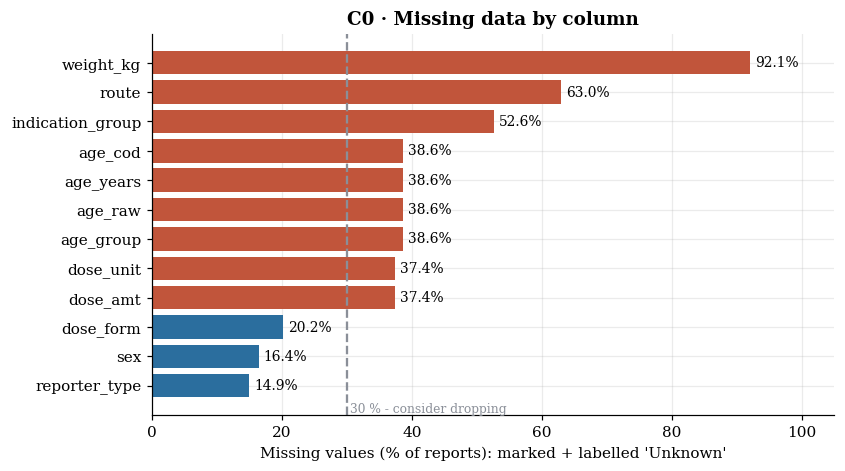

In [32]:
# Missing-rate bar (class: "console output, missing-rate bar"): the 12 most incomplete columns
top = inv.sort_values("true_missing_%", ascending=False).head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top["column"], top["true_missing_%"], color=[RED if v > 30 else BLUE for v in top["true_missing_%"]])
for y, v in enumerate(top["true_missing_%"]):
    ax.text(v + 0.8, y, f"{v:.1f}%", va="center", fontsize=9)
ax.axvline(30, ls="--", color=GREY); ax.text(30.5, -0.9, "30 % - consider dropping", color=GREY, fontsize=8)
ax.set_xlabel("Missing values (% of reports): marked + labelled 'Unknown'"); ax.set_xlim(0, 105)
ax.set_title("C0 · Missing data by column")
savefig("C0_missing_rate_by_column"); plt.show()

### 2b · Build the helper columns

In [33]:
df = reports.copy()
df["drug_label"] = df["drug"].str.title()

df["reporter_plot"] = df["reporter_type"]
share = df["reporter_plot"].value_counts(normalize=True)
df.loc[df["reporter_plot"].isin(share[share < 0.01].index), "reporter_plot"] = "Other (<1%)"

PREFERRED = list(REPORTER_TYPES.values()) + ["Other (<1%)", "Unknown"]
REPORTER_ORDER = [r for r in PREFERRED if r in set(df["reporter_plot"])]
REPORTER_ORDER += [r for r in df["reporter_plot"].unique() if r not in REPORTER_ORDER]

print("reporter_plot:", df["reporter_plot"].value_counts().to_dict())
print("drug_label:   ", df["drug_label"].value_counts().to_dict())
OVERALL = 100 * df["is_serious"].mean()
print(f"\nOverall % serious = {OVERALL:.1f}%   (positives: {int(df['is_serious'].sum()):,} of {len(df):,})")
d = df       # analysis frame (no NaN in is_serious, asserted above)

reporter_plot: {'Consumer': 186501, 'Unknown': 37626, 'Physician': 13212, 'Health professional': 8943, 'Pharmacist': 4711, 'Other (<1%)': 1575}
drug_label:    {'Tirzepatide': 151590, 'Semaglutide': 67110, 'Dulaglutide': 28403, 'Liraglutide': 5465}

Overall % serious = 11.3%   (positives: 28,497 of 252,568)


## 3 · E2 — % serious by drug
**Question:** *Among reported cases, which GLP-1 drug has the largest share of serious reports?*
Class design choices: **sorted horizontal bar** (default for an amount) · **whiskers = 95 % interval** (uncertainty plot: a bar without a range pretends to be exact) · **right panel = counts** ("the bar chart draws Electric (n=2) exactly as confidently as Diesel (n=3,205). Count before you compare") · **dashed line = overall %**.

saved -> /content/data230-group4-project/figures/E2_pct_serious_by_drug.png


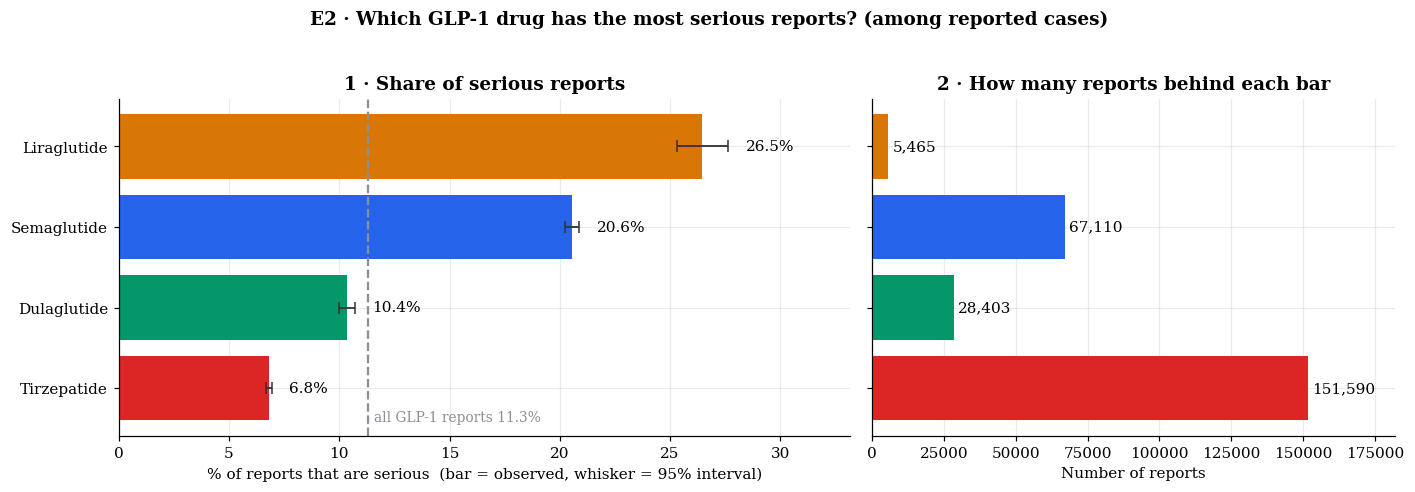

,drug_label,n,n_serious,pct,lo,hi
0,Tirzepatide,151590,10316,6.81,6.68,6.93
1,Dulaglutide,28403,2940,10.35,10.00,10.71
2,Semaglutide,67110,13795,20.56,20.25,20.86
3,Liraglutide,5465,1446,26.46,25.31,27.65


In [34]:
e2 = d.groupby("drug_label")["is_serious"].agg(n="size", n_serious="sum").reset_index()
e2["pct"] = 100 * e2["n_serious"] / e2["n"]
lo, hi = wilson(e2["n_serious"], e2["n"]); e2["lo"], e2["hi"] = 100 * lo, 100 * hi
e2 = e2.sort_values("pct").reset_index(drop=True)                  # ascending -> highest bar on top
colors = [drug_color(x.lower()) for x in e2["drug_label"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True, gridspec_kw={"width_ratios": [1.4, 1]})
ax1.barh(e2["drug_label"], e2["pct"], color=colors, xerr=[e2["pct"] - e2["lo"], e2["hi"] - e2["pct"]],
         capsize=4, ecolor="#333", error_kw={"lw": 1.2})
for y, r in e2.iterrows():
    ax1.text(r["hi"] + 0.8, y, f"{r['pct']:.1f}%", va="center", fontsize=10)
ax1.axvline(OVERALL, ls="--", color=GREY)
ax1.text(OVERALL + 0.3, -0.45, f"all GLP-1 reports {OVERALL:.1f}%", color=GREY, fontsize=9, va="bottom")
ax1.set_xlabel("% of reports that are serious  (bar = observed, whisker = 95% interval)")
ax1.set_xlim(0, max(e2["hi"]) * 1.2); ax1.set_title("1 · Share of serious reports")

ax2.barh(e2["drug_label"], e2["n"], color=colors)
for y, r in e2.iterrows():
    ax2.text(r["n"] + e2["n"].max() * 0.01, y, f"{int(r['n']):,}", va="center", fontsize=10)
ax2.set_xlim(0, e2["n"].max() * 1.2); ax2.set_xlabel("Number of reports"); ax2.set_title("2 · How many reports behind each bar")
fig.suptitle("E2 · Which GLP-1 drug has the most serious reports? (among reported cases)", fontweight="bold", y=1.03)
plt.tight_layout(); savefig("E2_pct_serious_by_drug"); plt.show()
display(e2.round(2))

In [35]:
# Is the drug difference bigger than chance?  (class: categorical x categorical -> chi-square)
ct = pd.crosstab(d["drug_label"], d["is_serious"])
chi2, p, dof, v_e2 = cramers_v(ct)
print(f"chi-square = {chi2:,.1f}, dof = {dof}, p {fmt_p(p)}, Cramér's V = {v_e2:.3f}")

top, bot = e2.iloc[-1], e2.iloc[0]
print("\nINSIGHT (auto-generated - re-read after the FINAL run before pasting into the slide):")
print(f"  Among reported cases, {top['drug_label']} has the highest share of serious reports ({top['pct']:.1f}%, n={int(top['n']):,}) "
      f"and {bot['drug_label']} the lowest ({bot['pct']:.1f}%, n={int(bot['n']):,}); all GLP-1 reports: {OVERALL:.1f}%.")
print(f"  The drug differences are statistically clear (chi-square p {fmt_p(p)}) but the effect size is "
      f"{'small' if v_e2 < 0.1 else 'moderate' if v_e2 < 0.3 else 'large'} (V = {v_e2:.2f}).")
print("DECISION:")
print("  1) Do NOT call a drug 'safer' from this chart alone - E6 checks who is reporting.")
print(f"  2) 'Serious' is the ML target and only {OVERALL:.1f}% of reports are positive -> class imbalance: class weights / resampling, judge models with PR-AUC or F1, not accuracy.")

chi-square = 10,083.4, dof = 3, p < 1e-300, Cramér's V = 0.200

INSIGHT (auto-generated - re-read after the FINAL run before pasting into the slide):
  Among reported cases, Liraglutide has the highest share of serious reports (26.5%, n=5,465) and Tirzepatide the lowest (6.8%, n=151,590); all GLP-1 reports: 11.3%.
  The drug differences are statistically clear (chi-square p < 1e-300) but the effect size is moderate (V = 0.20).
DECISION:
  1) Do NOT call a drug 'safer' from this chart alone - E6 checks who is reporting.
  2) 'Serious' is the ML target and only 11.3% of reports are positive -> class imbalance: class weights / resampling, judge models with PR-AUC or F1, not accuracy.


## 4 · E6 — Who reported it?
The hand-off warns that *"many tirzepatide reports come from patients about small problems"*. A consumer and a physician do not report the same kind of event, so we test it in three steps (a). who reports, (b) % serious inside each reporter type, (c) the gap with the reporter mix held constant.

### E6a · Reporter mix by drug
**Question:** *Who files the reports for each drug?* A 100 % stacked bar shows a composition; the number at the right shows the count it is built on.

saved -> /content/data230-group4-project/figures/E6a_reporter_mix_by_drug.png


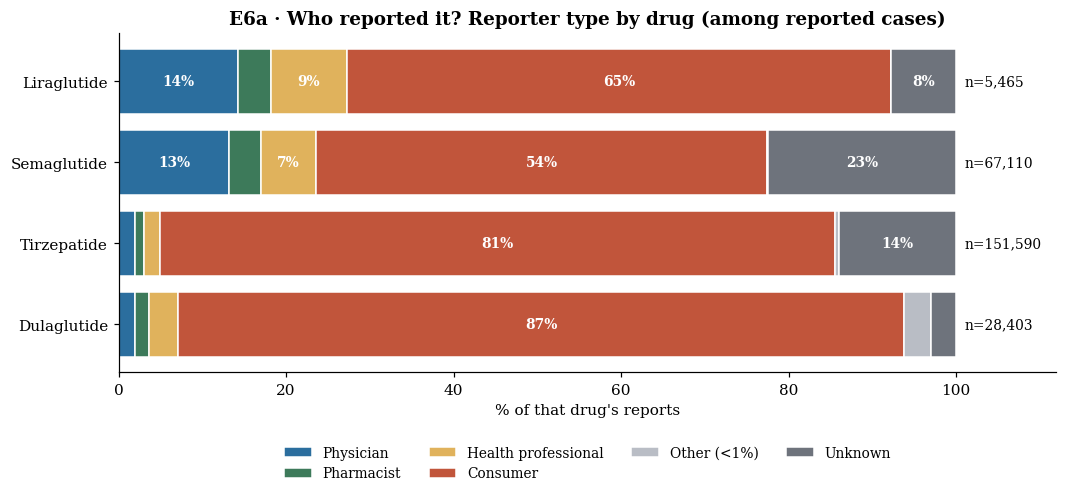

drug x reporter: chi-square p < 1e-300, Cramér's V = 0.21

INSIGHT (auto-generated):
  Consumer share of reports: Dulaglutide 87%, Tirzepatide 81%, Liraglutide 65%, Semaglutide 54%.
  Reporter mix differs by drug (V = 0.21), so raw % serious is NOT a like-for-like comparison.


In [36]:
mix = pd.crosstab(d["drug_label"], d["reporter_plot"]).reindex(columns=REPORTER_ORDER, fill_value=0)
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100
order = list(mix_pct.sort_values(REPORTER_ORDER[0], ascending=True).index)       # sorted by first category (Consumer)
mix_pct, mix = mix_pct.loc[order], mix.loc[order]

pal = {"Consumer": RED, "Physician": BLUE, "Pharmacist": GREEN, "Other health professional": ORANGE,
       "Health professional": "#E0B25C", "Lawyer": "#7B5EA7", "Other (<1%)": "#B9BDC5", "Unknown": "#6E737C"}
fig, ax = plt.subplots(figsize=(11, 4.0))
left = np.zeros(len(mix_pct))
for r in REPORTER_ORDER:
    ax.barh(mix_pct.index, mix_pct[r], left=left, color=pal.get(r, GREY), label=r, edgecolor="white")
    for y, (l, w) in enumerate(zip(left, mix_pct[r])):
        if w >= 6: ax.text(l + w / 2, y, f"{w:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    left += mix_pct[r].values
for y, drug in enumerate(mix.index):
    ax.text(101, y, f"n={int(mix.loc[drug].sum()):,}", va="center", fontsize=9)
ax.set_xlim(0, 112); ax.set_xlabel("% of that drug's reports"); ax.grid(False)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False, fontsize=9)
ax.set_title("E6a · Who reported it? Reporter type by drug (among reported cases)")
savefig("E6a_reporter_mix_by_drug"); plt.show()

chi2, p, dof, v_mix = cramers_v(pd.crosstab(d["drug_label"], d["reporter_plot"]))
print(f"drug x reporter: chi-square p {fmt_p(p)}, Cramér's V = {v_mix:.2f}")
cons = mix_pct["Consumer"]
print("\nINSIGHT (auto-generated):")
print("  Consumer share of reports: " + ", ".join(f"{k} {val:.0f}%" for k, val in cons.sort_values(ascending=False).items()) + ".")
print(f"  Reporter mix differs by drug (V = {v_mix:.2f}), so raw % serious is NOT a like-for-like comparison.")

## 5 ·The decision table
The output of an EDA is a decision table

In [37]:
dec = pd.DataFrame([
    ("weight_kg", "do not use", f"{inv.set_index('column').loc['weight_kg', 'true_missing_%']:.1f}% missing (hand-off rule 1)"),
    ("is_serious", "use as the ML target; never use is_death / is_life_threatening / is_hospitalized / is_disability as features", f"leakage; positives = {OVERALL:.1f}% (imbalanced); OT 'other serious' is not counted"),
    ("reporter_type", "keep as a feature and as a stratifier; 'Unknown' stays a category; HP and OT stay separate", f"{(df['reporter_type'] == 'Unknown').mean() * 100:.1f}% unknown; mix differs by drug (V={v_mix:.2f})"),
    ("drug x reporter cells with n < 30", "hide / do not compare", f"{len(hidden)} cells hidden - tiny groups give unstable percentages"),
    ("raw % serious by drug (E2)", "show with 95% interval and n; never as a safety ranking", "reports, not rates; reporter mix differs"),
    ("drug gap in % serious", "report the standardised gap with its interval next to the raw one", f"{B} - {A}: {g_obs:.1f} -> {g_std:.1f} points [{ci_std[0]:.1f}, {ci_std[1]:.1f}] after standardising"),
    ("pooled years (final file)", "check E6d before pooling 2022-2026", "a time trend can masquerade as a drug effect"),
    ("modelling target", "classification with class weights or resampling; score with PR-AUC / F1, not accuracy", f"positive class = {OVERALL:.1f}%"),
], columns=["Column / issue", "Decision", "Because"])
pd.set_option("display.max_colwidth", 140)
display(dec)

,Column / issue,Decision,Because
0,weight_kg,do not use,92.1% missing (hand-off rule 1)
1,is_serious,use as the ML target; never use is_death / is_life_threatening / is_hospitalized / is_disability as features,leakage; positives = 11.3% (imbalanced); OT 'other serious' is not counted
2,reporter_type,keep as a feature and as a stratifier; 'Unknown' stays a category; HP and OT stay separate,14.9% unknown; mix differs by drug (V=0.21)
3,drug x reporter cells with n < 30,hide / do not compare,2 cells hidden - tiny groups give unstable percentages
4,raw % serious by drug (E2),show with 95% interval and n; never as a safety ranking,"reports, not rates; reporter mix differs"
5,drug gap in % serious,report the standardised gap with its interval next to the raw one,"Semaglutide - Tirzepatide: 13.8 -> 11.5 points [11.2, 11.9] after standardising"
6,pooled years (final file),check E6d before pooling 2022-2026,a time trend can masquerade as a drug effect
7,modelling target,"classification with class weights or resampling; score with PR-AUC / F1, not accuracy",positive class = 11.3%


## 6 · Save everything
Figures were already written to `<repo>/figures/`. In Colab the next cell zips them and downloads the zip to your laptop, so you can add them to the repo and commit.

In [38]:
import zipfile
print("Figures written this run:")
for p in SAVED: print("  ", p)
dec.to_csv(PROJECT_ROOT / "reports" / f"E2_E6_decision_table{SUFFIX}.csv", index=False) if (PROJECT_ROOT / "reports").exists() else None

if IN_COLAB:
    zpath = "/content/karishma_E2_E6_outputs.zip"
    with zipfile.ZipFile(zpath, "w") as z:
        for p in SAVED: z.write(p, arcname=f"figures/{p.name}")
        t = PROJECT_ROOT / "reports" / f"E2_E6_decision_table{SUFFIX}.csv"
        if t.exists(): z.write(t, arcname=f"reports/{t.name}")
    from google.colab import files
    files.download(zpath)

Figures written this run:
   /content/data230-group4-project/figures/C0_missing_rate_by_column.png
   /content/data230-group4-project/figures/E2_pct_serious_by_drug.png
   /content/data230-group4-project/figures/E6a_reporter_mix_by_drug.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>